# Linear Regression and Regularization

## Objective

Implement Linear Regression, evaluate using MAE, MSE, RMSE and R², then apply Ridge and Lasso Regression and compare results.

## Dataset

Use sklearn California Housing dataset (fetch_california_housing).
The dataset contains information collected from districts in California, such as:
- Median income 
- Average house age 
- Average number of rooms 
- Population 
- Latitude 
- Longitude 
- Median house value (target)


In [1]:

# 1. Import required libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# 2. Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
# 3. Explore the dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
# 4. Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [8]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# 6. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 7. Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [11]:
# 8. Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
# 9. Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_y_pred = ridge_model.predict(X_test_scaled)

In [13]:
# 10. Lasso
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)    
lasso_y_pred = lasso_model.predict(X_test_scaled)

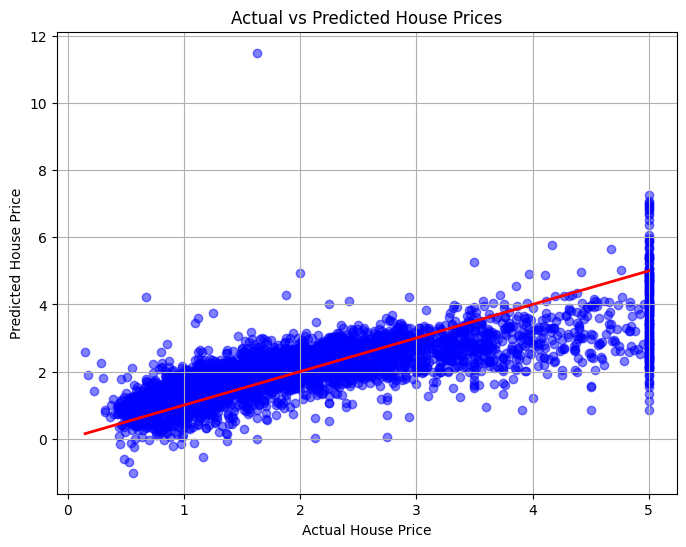

In [14]:
# 11. Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

# Ideal prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices')

plt.grid(True)
plt.show()

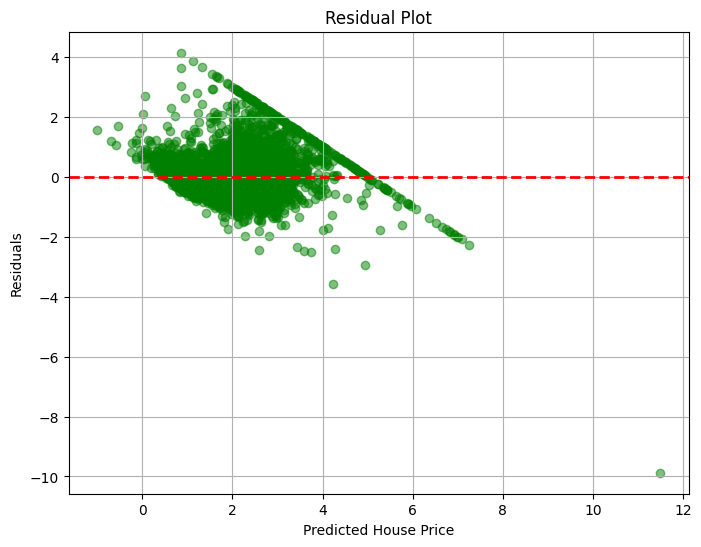

In [15]:
# 12. Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted House Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

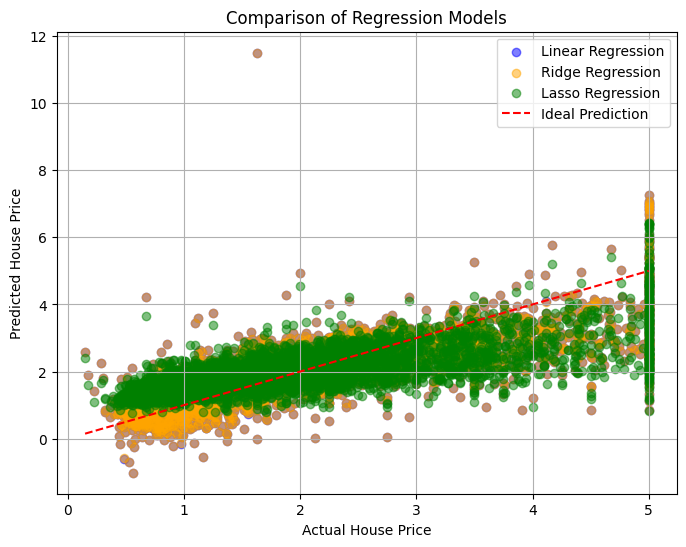

In [16]:
# 13. Compare linear regression, ridge regression, and lasso regression graphically
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(y_test, ridge_y_pred, color='orange', alpha=0.5, label='Ridge Regression')
plt.scatter(y_test, lasso_y_pred, color='green', alpha=0.5, label='Lasso Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', label='Ideal Prediction')

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Comparison of Regression Models')
plt.legend()

plt.grid(True)
plt.show()

In [17]:
print(f"Linear Regression - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

Linear Regression - MAE: 0.5332, MSE: 0.5559, RMSE: 0.7456, R2: 0.5758


In [18]:
mae_ridge = mean_absolute_error(y_test, ridge_y_pred)
mse_ridge = mean_squared_error(y_test, ridge_y_pred)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, ridge_y_pred)

print(f"Ridge Regression - MAE: {mae_ridge:.4f}, MSE: {mse_ridge:.4f}, RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")

Ridge Regression - MAE: 0.5332, MSE: 0.5559, RMSE: 0.7456, R2: 0.5758


In [19]:
mae_lasso = mean_absolute_error(y_test, lasso_y_pred)
mse_lasso = mean_squared_error(y_test, lasso_y_pred)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, lasso_y_pred)

print(f"Lasso Regression - MAE: {mae_lasso:.4f}, MSE: {mse_lasso:.4f}, RMSE: {rmse_lasso:.4f}, R2: {r2_lasso:.4f}")

Lasso Regression - MAE: 0.6222, MSE: 0.6796, RMSE: 0.8244, R2: 0.4814


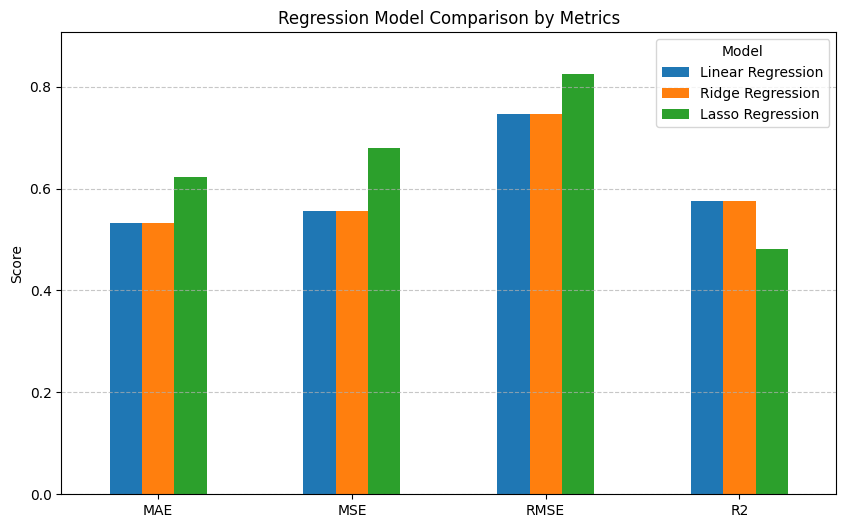

In [20]:
metrics_df = pd.DataFrame({
    'Linear Regression': [mae, mse, rmse, r2],
    'Ridge Regression': [mae_ridge, mse_ridge, rmse_ridge, r2_ridge],
    'Lasso Regression': [mae_lasso, mse_lasso, rmse_lasso, r2_lasso]
}, index=['MAE', 'MSE', 'RMSE', 'R2'])

ax = metrics_df.plot(kind='bar', figsize=(10, 6))
ax.set_ylabel('Score')
ax.set_title('Regression Model Comparison by Metrics')
ax.set_ylim(0, max(metrics_df.max()) * 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()